# Statistics Advance-5 Assignment
### Data Science Masters - PW Skills

## Q1. 95% Confidence Interval — mean=50, std=5

In [1]:
import numpy as np
from scipy import stats

sample_mean = 50
sample_std  = 5
n           = 30       # assumed sample size
confidence  = 0.95

z_critical      = stats.norm.ppf((1 + confidence) / 2)
margin_of_error = z_critical * (sample_std / np.sqrt(n))
lower = sample_mean - margin_of_error
upper = sample_mean + margin_of_error

print("===== 95% Confidence Interval =====")
print(f"Sample Mean     : {sample_mean}")
print(f"Sample Std      : {sample_std}")
print(f"n               : {n}")
print(f"Z-critical      : {z_critical:.4f}")
print(f"Margin of Error : {margin_of_error:.4f}")
print(f"\n95% CI: ({lower:.2f}, {upper:.2f})")
print(f"\nInterpretation: We are 95% confident the true population mean")
print(f"lies between {lower:.2f} and {upper:.2f}.")

===== 95% Confidence Interval =====
Sample Mean     : 50
Sample Std      : 5
n               : 30
Z-critical      : 1.9600
Margin of Error : 1.7892

95% CI: (48.21, 51.79)

Interpretation: We are 95% confident the true population mean
lies between 48.21 and 51.79.


## Q2. Chi-square Goodness of Fit — M&Ms color distribution

In [2]:
import numpy as np
from scipy.stats import chisquare

# Expected distribution: 20% blue, 20% orange, 20% green, 10% yellow, 10% red, 20% brown
# Simulated observed counts from a bag of 100 M&Ms
observed  = np.array([23, 18, 22, 8,  12, 17])   # blue, orange, green, yellow, red, brown
expected_p = np.array([0.20, 0.20, 0.20, 0.10, 0.10, 0.20])
expected  = expected_p * sum(observed)            # scale to total count

chi2_stat, p_value = chisquare(f_obs=observed, f_exp=expected)

alpha = 0.05
colors = ['Blue', 'Orange', 'Green', 'Yellow', 'Red', 'Brown']

print("===== Chi-Square Goodness of Fit — M&Ms =====")
print(f"{'Color':<10} {'Observed':>10} {'Expected':>10}")
print("-" * 32)
for c, o, e in zip(colors, observed, expected):
    print(f"{c:<10} {o:>10} {e:>10.1f}")

print(f"\nChi-square statistic : {chi2_stat:.4f}")
print(f"p-value              : {p_value:.4f}")
print(f"Alpha                : {alpha}")

if p_value < alpha:
    print("\nResult: REJECT H₀ — Distribution does NOT match expected M&Ms distribution.")
else:
    print("\nResult: FAIL TO REJECT H₀ — Distribution matches expected M&Ms distribution.")

===== Chi-Square Goodness of Fit — M&Ms =====
Color        Observed   Expected
--------------------------------
Blue               23       20.0
Orange             18       20.0
Green              22       20.0
Yellow              8       10.0
Red                12       10.0
Brown              17       20.0

Chi-square statistic : 2.1000
p-value              : 0.8351
Alpha                : 0.05

Result: FAIL TO REJECT H₀ — Distribution matches expected M&Ms distribution.


## Q3. Chi-square statistic and p-value — Contingency table (Group A vs Group B)

In [3]:
import numpy as np
from scipy.stats import chi2_contingency
import pandas as pd

# Contingency table
#           Group A   Group B
# Outcome 1   20        15
# Outcome 2   10        25
# Outcome 3   15        20

table = np.array([[20, 15],
                  [10, 25],
                  [15, 20]])

df_table = pd.DataFrame(table,
                        index=['Outcome 1', 'Outcome 2', 'Outcome 3'],
                        columns=['Group A', 'Group B'])
print("Contingency Table:")
print(df_table)

chi2_stat, p_value, dof, expected = chi2_contingency(table)

alpha = 0.05
print(f"\nChi-square statistic : {chi2_stat:.4f}")
print(f"p-value              : {p_value:.4f}")
print(f"Degrees of freedom   : {dof}")
print(f"\nExpected frequencies:")
print(np.round(expected, 2))

if p_value < alpha:
    print("\nResult: REJECT H₀ — Significant association between group and outcome.")
else:
    print("\nResult: FAIL TO REJECT H₀ — No significant association between group and outcome.")

Contingency Table:
           Group A  Group B
Outcome 1       20       15
Outcome 2       10       25
Outcome 3       15       20

Chi-square statistic : 5.8333
p-value              : 0.0541
Degrees of freedom   : 2

Expected frequencies:
[[15. 20.]
 [15. 20.]
 [15. 20.]]

Result: FAIL TO REJECT H₀ — No significant association between group and outcome.


## Q4. 95% CI for proportion — Smoking prevalence (60 out of 500)

In [4]:
import numpy as np
from scipy import stats

n          = 500
smokers    = 60
p_hat      = smokers / n    # 0.12
confidence = 0.95

z_critical      = stats.norm.ppf((1 + confidence) / 2)
se              = np.sqrt((p_hat * (1 - p_hat)) / n)
margin_of_error = z_critical * se
lower = p_hat - margin_of_error
upper = p_hat + margin_of_error

print("===== 95% CI for Smoking Proportion =====")
print(f"Sample size       : {n}")
print(f"Smokers           : {smokers}")
print(f"Sample proportion : {p_hat:.4f} ({p_hat*100:.1f}%)")
print(f"Z-critical        : {z_critical:.4f}")
print(f"Standard Error    : {se:.4f}")
print(f"Margin of Error   : {margin_of_error:.4f}")
print(f"\n95% CI: ({lower:.4f}, {upper:.4f})")
print(f"       = ({lower*100:.2f}%, {upper*100:.2f}%)")
print(f"\nInterpretation: We are 95% confident that the true proportion of smokers")
print(f"in the population lies between {lower*100:.2f}% and {upper*100:.2f}%.")

===== 95% CI for Smoking Proportion =====
Sample size       : 500
Smokers           : 60
Sample proportion : 0.1200 (12.0%)
Z-critical        : 1.9600
Standard Error    : 0.0145
Margin of Error   : 0.0285

95% CI: (0.0915, 0.1485)
       = (9.15%, 14.85%)

Interpretation: We are 95% confident that the true proportion of smokers
in the population lies between 9.15% and 14.85%.


## Q5. 90% Confidence Interval — mean=75, std=12

In [5]:
import numpy as np
from scipy import stats

sample_mean = 75
sample_std  = 12
n           = 30      # assumed
confidence  = 0.90

z_critical      = stats.norm.ppf((1 + confidence) / 2)
margin_of_error = z_critical * (sample_std / np.sqrt(n))
lower = sample_mean - margin_of_error
upper = sample_mean + margin_of_error

print("===== 90% Confidence Interval =====")
print(f"Sample Mean     : {sample_mean}")
print(f"Sample Std      : {sample_std}")
print(f"n               : {n}")
print(f"Z-critical      : {z_critical:.4f}")
print(f"Margin of Error : {margin_of_error:.4f}")
print(f"\n90% CI: ({lower:.2f}, {upper:.2f})")
print(f"\nInterpretation: We are 90% confident the true population mean")
print(f"lies between {lower:.2f} and {upper:.2f}.")

===== 90% Confidence Interval =====
Sample Mean     : 75
Sample Std      : 12
n               : 30
Z-critical      : 1.6449
Margin of Error : 3.6037

90% CI: (71.40, 78.60)

Interpretation: We are 90% confident the true population mean
lies between 71.40 and 78.60.


## Q6. Chi-square distribution plot (df=10) with shaded area at chi2=15

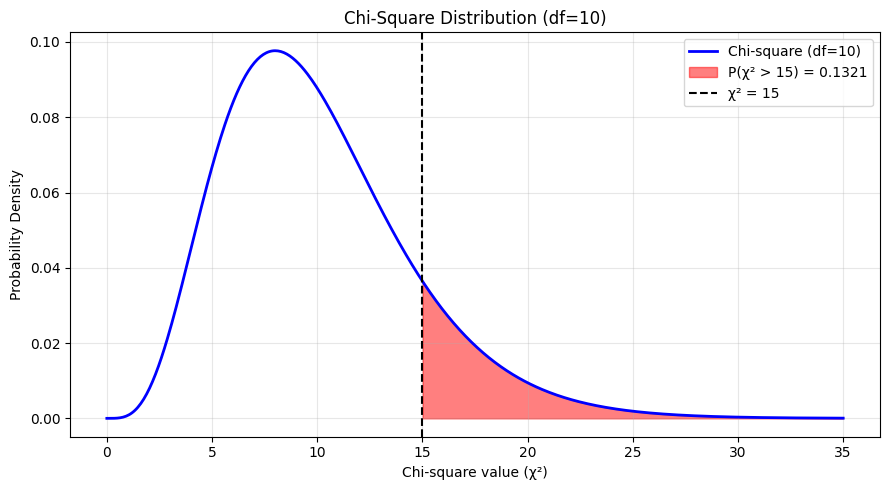

P(χ² > 15) with df=10 : 0.1321


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

df       = 10
chi2_val = 15
x = np.linspace(0, 35, 500)
y = chi2.pdf(x, df=df)

plt.figure(figsize=(9, 5))
plt.plot(x, y, 'b-', linewidth=2, label=f'Chi-square (df={df})')

# Shade area to the right of chi2=15
plt.fill_between(x, y, where=(x >= chi2_val), color='red', alpha=0.5,
                 label=f'P(χ² > {chi2_val}) = {chi2.sf(chi2_val, df):.4f}')

plt.axvline(chi2_val, color='black', linestyle='--', label=f'χ² = {chi2_val}')
plt.title(f'Chi-Square Distribution (df={df})')
plt.xlabel('Chi-square value (χ²)')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"P(χ² > 15) with df=10 : {chi2.sf(chi2_val, df):.4f}")

## Q7. 99% CI for proportion — Coke vs Pepsi (520 out of 1000)

In [7]:
import numpy as np
from scipy import stats

n          = 1000
coke_fans  = 520
p_hat      = coke_fans / n   # 0.52
confidence = 0.99

z_critical      = stats.norm.ppf((1 + confidence) / 2)
se              = np.sqrt((p_hat * (1 - p_hat)) / n)
margin_of_error = z_critical * se
lower = p_hat - margin_of_error
upper = p_hat + margin_of_error

print("===== 99% CI for Coke Preference =====")
print(f"Sample size        : {n}")
print(f"Prefer Coke        : {coke_fans}")
print(f"Sample proportion  : {p_hat:.4f} ({p_hat*100:.1f}%)")
print(f"Z-critical (99%)   : {z_critical:.4f}")
print(f"Standard Error     : {se:.4f}")
print(f"Margin of Error    : {margin_of_error:.4f}")
print(f"\n99% CI: ({lower:.4f}, {upper:.4f})")
print(f"       = ({lower*100:.2f}%, {upper*100:.2f}%)")
print(f"\nInterpretation: We are 99% confident the true proportion of Coke preferrers")
print(f"lies between {lower*100:.2f}% and {upper*100:.2f}%.")

===== 99% CI for Coke Preference =====
Sample size        : 1000
Prefer Coke        : 520
Sample proportion  : 0.5200 (52.0%)
Z-critical (99%)   : 2.5758
Standard Error     : 0.0158
Margin of Error    : 0.0407

99% CI: (0.4793, 0.5607)
       = (47.93%, 56.07%)

Interpretation: We are 99% confident the true proportion of Coke preferrers
lies between 47.93% and 56.07%.


## Q8. Chi-square Goodness of Fit — Biased Coin (45 tails in 100 flips)

In [8]:
import numpy as np
from scipy.stats import chisquare

# H0: coin is fair → P(H) = P(T) = 0.5
# H1: coin is biased towards tails

n_flips  = 100
observed = np.array([55, 45])   # [Heads, Tails]
expected = np.array([50, 50])   # fair coin

chi2_stat, p_value = chisquare(f_obs=observed, f_exp=expected)

alpha = 0.05
print("===== Chi-Square Goodness of Fit — Coin Bias Test =====")
print(f"H₀: Coin is fair (P(H) = P(T) = 0.5)")
print(f"H₁: Coin is biased towards tails")
print(f"\n{'Outcome':<10} {'Observed':>10} {'Expected':>10}")
print("-" * 32)
print(f"{'Heads':<10} {observed[0]:>10} {expected[0]:>10}")
print(f"{'Tails':<10} {observed[1]:>10} {expected[1]:>10}")
print(f"\nChi-square statistic : {chi2_stat:.4f}")
print(f"p-value              : {p_value:.4f}")
print(f"Alpha                : {alpha}")

if p_value < alpha:
    print("\nResult: REJECT H₀ — Coin is significantly biased.")
else:
    print("\nResult: FAIL TO REJECT H₀ — No significant evidence that coin is biased.")

===== Chi-Square Goodness of Fit — Coin Bias Test =====
H₀: Coin is fair (P(H) = P(T) = 0.5)
H₁: Coin is biased towards tails

Outcome      Observed   Expected
--------------------------------
Heads              55         50
Tails              45         50

Chi-square statistic : 1.0000
p-value              : 0.3173
Alpha                : 0.05

Result: FAIL TO REJECT H₀ — No significant evidence that coin is biased.


## Q9. Chi-square Test for Independence — Smoking and Lung Cancer

In [9]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

#                Lung Cancer: Yes   Lung Cancer: No
# Smoker                60               140
# Non-smoker            30               170

table = np.array([[60, 140],
                  [30, 170]])

df_table = pd.DataFrame(table,
                        index=['Smoker', 'Non-smoker'],
                        columns=['Lung Cancer: Yes', 'Lung Cancer: No'])
print("Contingency Table:")
print(df_table)

chi2_stat, p_value, dof, expected = chi2_contingency(table)

alpha = 0.05
print(f"\nChi-square statistic : {chi2_stat:.4f}")
print(f"p-value              : {p_value:.4f}")
print(f"Degrees of freedom   : {dof}")
print(f"Expected frequencies:")
print(pd.DataFrame(np.round(expected, 2),
                   index=['Smoker', 'Non-smoker'],
                   columns=['Lung Cancer: Yes', 'Lung Cancer: No']))

if p_value < alpha:
    print("\nResult: REJECT H₀ — Significant association between smoking and lung cancer.")
else:
    print("\nResult: FAIL TO REJECT H₀ — No significant association between smoking and lung cancer.")

Contingency Table:
            Lung Cancer: Yes  Lung Cancer: No
Smoker                    60              140
Non-smoker                30              170

Chi-square statistic : 12.0573
p-value              : 0.0005
Degrees of freedom   : 1
Expected frequencies:
            Lung Cancer: Yes  Lung Cancer: No
Smoker                  45.0            155.0
Non-smoker              45.0            155.0

Result: REJECT H₀ — Significant association between smoking and lung cancer.


## Q10. Chi-square Test for Independence — Chocolate preference (US vs UK)

In [10]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

#              Milk Choc   Dark Choc   White Choc
# US (n=500)     200         150         150
# UK (n=500)     225         175         100

table = np.array([[200, 150, 150],
                  [225, 175, 100]])

df_table = pd.DataFrame(table,
                        index=['U.S.', 'U.K.'],
                        columns=['Milk Chocolate', 'Dark Chocolate', 'White Chocolate'])
print("Contingency Table:")
print(df_table)

chi2_stat, p_value, dof, expected = chi2_contingency(table)

alpha = 0.01
print(f"\nChi-square statistic : {chi2_stat:.4f}")
print(f"p-value              : {p_value:.4f}")
print(f"Degrees of freedom   : {dof}")
print(f"Alpha                : {alpha}")
print(f"\nExpected frequencies:")
print(pd.DataFrame(np.round(expected, 2),
                   index=['U.S.', 'U.K.'],
                   columns=['Milk Chocolate', 'Dark Chocolate', 'White Chocolate']))

if p_value < alpha:
    print("\nResult: REJECT H₀ — Significant association between chocolate preference and country.")
else:
    print("\nResult: FAIL TO REJECT H₀ — No significant association between chocolate preference and country.")

Contingency Table:
      Milk Chocolate  Dark Chocolate  White Chocolate
U.S.             200             150              150
U.K.             225             175              100

Chi-square statistic : 13.3937
p-value              : 0.0012
Degrees of freedom   : 2
Alpha                : 0.01

Expected frequencies:
      Milk Chocolate  Dark Chocolate  White Chocolate
U.S.           212.5           162.5            125.0
U.K.           212.5           162.5            125.0

Result: REJECT H₀ — Significant association between chocolate preference and country.


## Q11. Hypothesis test — Population mean significantly different from 70? (α=0.05)

In [11]:
import numpy as np
from scipy import stats

# Given
n           = 30
sample_mean = 72
sample_std  = 10
mu_0        = 70     # hypothesized population mean
alpha       = 0.05

# H0: μ = 70
# H1: μ ≠ 70  (two-tailed)

t_stat  = (sample_mean - mu_0) / (sample_std / np.sqrt(n))
p_value = 2 * stats.t.sf(abs(t_stat), df=n-1)   # two-tailed

t_critical = stats.t.ppf(1 - alpha/2, df=n-1)

print("===== One-Sample t-Test =====")
print(f"H₀: μ = {mu_0}")
print(f"H₁: μ ≠ {mu_0} (two-tailed)")
print(f"\nSample mean   : {sample_mean}")
print(f"Sample std    : {sample_std}")
print(f"n             : {n}")
print(f"t-statistic   : {t_stat:.4f}")
print(f"t-critical    : ±{t_critical:.4f}")
print(f"p-value       : {p_value:.4f}")
print(f"Alpha         : {alpha}")

if p_value < alpha:
    print("\nResult: REJECT H₀ — Population mean is significantly different from 70.")
else:
    print("\nResult: FAIL TO REJECT H₀ — Population mean is NOT significantly different from 70.")

===== One-Sample t-Test =====
H₀: μ = 70
H₁: μ ≠ 70 (two-tailed)

Sample mean   : 72
Sample std    : 10
n             : 30
t-statistic   : 1.0954
t-critical    : ±2.0452
p-value       : 0.2823
Alpha         : 0.05

Result: FAIL TO REJECT H₀ — Population mean is NOT significantly different from 70.
